/tmp/ipykernel_159545/317309526.py:129: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=0, fontsize=20)


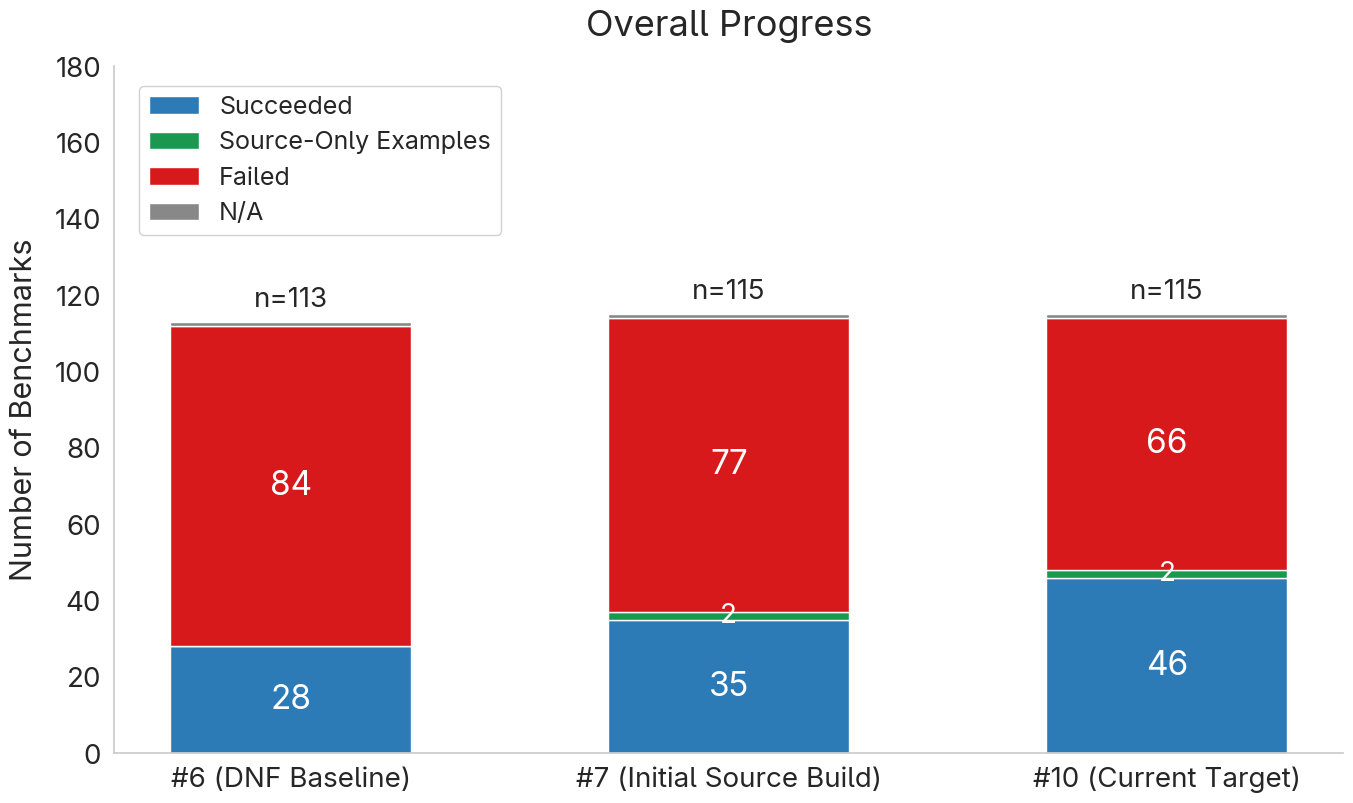

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set overall plot theme and font family
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Adwaita Sans"

fig, ax = plt.subplots(figsize=(14, 8.5))

labels = [
    "#6 (DNF Baseline)",
    "#7 (Initial Source Build)",
    "#10 (Current Target)",
]

# Color palette definition
SUCCESS_BLUE = "#2c7bb6"
EXTRA_GREEN = "#1a9850"
FAILURE_RED = "#d7191c"
NA_GREY = "#888888"

# Data series accounting for 1 N/A benchmark per run (only hip_multi_gpu_data_transfer is NA till now)
# #6 Total = 28 + 0 + 84 + 1 = 113
# #7 Total = 35 + 2 + 77 + 1 = 115
# #10 Total = 46 + 2 + 66 + 1 = 115
success_values = [28, 35, 46]
green_values = [0, 2, 2]
failure_values = [84, 77, 66]
na_values = [1, 1, 1]

# Bottom height offsets for stacking layers correctly
bottom_green = [s for s in success_values]
bottom_failure = [s + g for s, g in zip(success_values, green_values)]
bottom_na = [
    s + g + f for s, g, f in zip(success_values, green_values, failure_values)
]

# Bar layers stacked from bottom to top: Blue -> Green -> Red -> Grey
ax.bar(
    labels,
    success_values,
    color=SUCCESS_BLUE,
    label="Succeeded",
    width=0.55,
)
ax.bar(
    labels,
    green_values,
    bottom=bottom_green,
    color=EXTRA_GREEN,
    label="Source-Only Examples",
    width=0.55,
)
ax.bar(
    labels,
    failure_values,
    bottom=bottom_failure,
    color=FAILURE_RED,
    label="Failed",
    width=0.55,
)
ax.bar(
    labels,
    na_values,
    bottom=bottom_na,
    color=NA_GREY,
    label="N/A",
    width=0.55,
)

# Text labels inside bars (UNBOLDED regular font weight)
for i in range(len(labels)):
  # Blue layer
  if success_values[i] > 0:
    ax.text(
        i,
        success_values[i] / 2,
        str(success_values[i]),
        ha="center",
        va="center",
        fontsize=24,
        color="white",
        fontweight="normal",
    )
  # Green layer
  if green_values[i] >= 2:
    ax.text(
        i,
        bottom_green[i] + (green_values[i] / 2),
        str(green_values[i]),
        ha="center",
        va="center",
        fontsize=20,
        color="white",
        fontweight="normal",
    )
  # Red layer
  if failure_values[i] > 0:
    ax.text(
        i,
        bottom_failure[i] + (failure_values[i] / 2),
        str(failure_values[i]),
        ha="center",
        va="center",
        fontsize=24,
        color="white",
        fontweight="normal",
    )

  # Top n= total text (scaled up, unbolded)
  total = (
      success_values[i] + green_values[i] + failure_values[i] + na_values[i]
  )
  ax.text(i, total + 2.5, f"n={total}", ha="center", va="bottom", fontsize=20)

# Headroom expansion to prevent legend box overlap
ax.set_ylim(0, 180)

# Title & Axis Labels
ax.set_title(
    "Overall Progress",
    fontsize=26,
    pad=22,
)
ax.set_ylabel("Number of Benchmarks", fontsize=22, labelpad=12)
ax.set_xlabel("")

# Tick parameters
ax.set_xticklabels(labels, rotation=0, fontsize=20)
ax.tick_params(axis="y", labelsize=20)

# Legend setup matching requirements
legend = ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    fontsize=18,
    framealpha=0.9,
)

for text in legend.get_texts():
  text.set_fontfamily("Adwaita Sans")

ax.grid(False)
sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

plt.tight_layout(pad=2.0)
plt.savefig("hip_overall_progress_clean_unbolded.png", dpi=300, bbox_inches="tight")

In [10]:
import csv
import re
from pathlib import Path

# Color constants
GREEN = "#2ece68"  # Succeeded (Standard)
BLUE = "#3498db"   # Succeeded (Source-only)
RED = "#e74c3c"    # Failed
ORANGE = "#e67e22" # DNF (Did Not Finish)
GRAY = "#95a5a6"   # N/A

CSV_6 = Path("/home/netherquark/Soham/Large_code/sources/GPU/backrocm/graphs/gpus-6/benchmark_results.csv")
CSV_11 = Path("/home/netherquark/Soham/Large_code/sources/GPU/backrocm/graphs/gpus-11/benchmark_results.csv")

def extract_binary_name(raw_path: str) -> str:
    """Extract clean binary name from full execution path or raw string."""
    if not raw_path or raw_path == "N/A":
        return "N/A"
    path_obj = Path(raw_path.strip())
    return path_obj.name

def load_data():
    # Load baseline binaries from CSV 6
    baseline_binaries = set()
    with open(CSV_6, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f, delimiter='|')
        for row in reader:
            b_name = extract_binary_name(row['binary'])
            if b_name != "N/A":
                baseline_binaries.add(b_name)

    # Process CSV 11
    results = {
        "success_std": 0,
        "success_src": 0,
        "failed": 0,
        "dnf": 0,
        "na": 0,
        "details": []
    }

    with open(CSV_11, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f, delimiter='|')
        for row in reader:
            raw_binary = row['binary']
            status = row['status'].strip().upper()
            
            clean_name = extract_binary_name(raw_binary)

            if status == "SUCCESS":
                if clean_name in baseline_binaries:
                    category = "Succeeded (Standard)"
                    color = GREEN
                    results["success_std"] += 1
                else:
                    category = "Succeeded (Source-Only)"
                    color = BLUE
                    results["success_src"] += 1
            elif status == "FAILURE":
                category = "Failed"
                color = RED
                results["failed"] += 1
            elif status == "DNF":
                category = "Did Not Finish (DNF)"
                color = ORANGE
                results["dnf"] += 1
            else:
                category = "N/A"
                color = GRAY
                results["na"] += 1

            results["details"].append({
                "binary": clean_name,
                "status": status,
                "category": category,
                "color": color,
                "execution_time_ms": row.get("execution_time_ms", "N/A"),
                "error_category": row.get("error_category", "None")
            })

    return results

if __name__ == "__main__":
    data = load_data()
    print("=== Execution Breakdown ===")
    print(f"Succeeded (Standard):    {data['success_std']}")
    print(f"Succeeded (Source-Only): {data['success_src']}")
    print(f"Failed:                  {data['failed']}")
    print(f"DNF:                     {data['dnf']}")
    print(f"N/A:                     {data['na']}")
    print(f"Total Rows Processed:    {len(data['details'])}")

=== Execution Breakdown ===
Succeeded (Standard):    65
Succeeded (Source-Only): 22
Failed:                  53
DNF:                     1
N/A:                     0
Total Rows Processed:    141


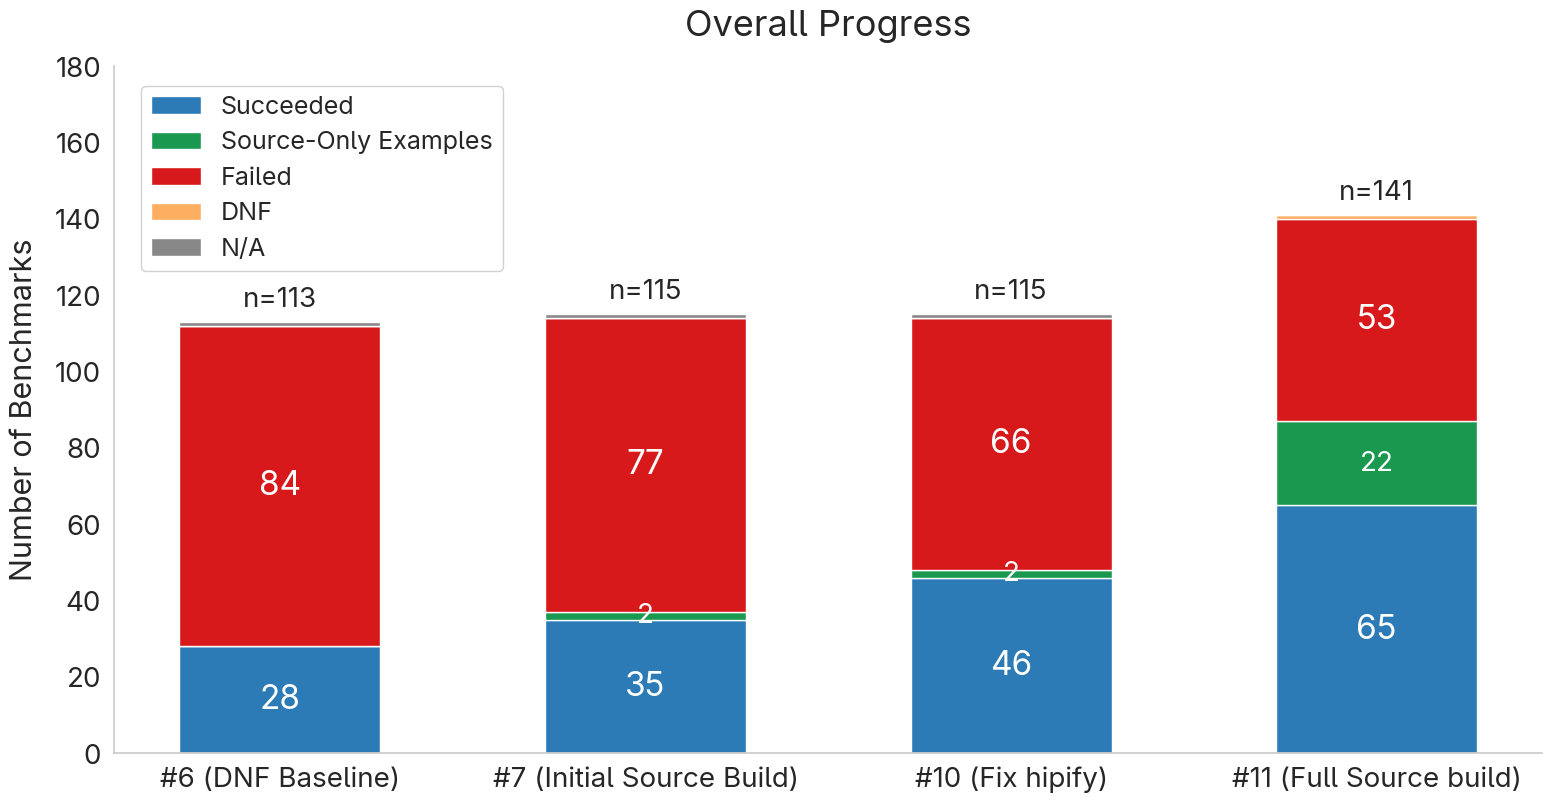

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# File paths
csv_6_path = "/home/netherquark/Soham/Large_code/sources/GPU/backrocm/graphs/gpus-6/benchmark_results.csv"
csv_11_path = "/home/netherquark/Soham/Large_code/sources/GPU/backrocm/graphs/gpus-11/benchmark_results.csv"

# Read CSVs with proper pipe delimiter
df6 = pd.read_csv(csv_6_path, sep="|")
df11 = pd.read_csv(csv_11_path, sep="|")

# Set of benchmark names present in run #6
binaries_baseline_6 = set(df6["binary"].dropna().unique())

# Identify source-only binaries present in run #11 but not in run #6
is_source_only_11 = ~df11["binary"].isin(binaries_baseline_6)

# Dynamic calculations for run #11
source_only_11 = (is_source_only_11 & (df11["status"] == "Success")).sum()
succeeded_11 = (~is_source_only_11 & (df11["status"] == "Success")).sum()
failed_11 = (df11["status"] == "Failure").sum()
dnf_11 = (df11["status"] == "DNF").sum()

# Multi-GPU succeeded in run #11, so N/A count is now 0 for run #11
na_11 = 0

# Set overall plot theme and font family
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Adwaita Sans"

fig, ax = plt.subplots(figsize=(16, 8.5))

labels = [
    "#6 (DNF Baseline)",
    "#7 (Initial Source Build)",
    "#10 (Fix hipify)",
    "#11 (Full Source build)",
]

# Color palette definition
SUCCESS_BLUE = "#2c7bb6"
EXTRA_GREEN = "#1a9850"
FAILURE_RED = "#d7191c"
DNF_ORANGE = "#fdae61"
NA_GREY = "#888888"

# Data series accounting for all 4 runs (#7 and #10 kept unchanged)
success_values = [28, 35, 46, succeeded_11]
green_values = [0, 2, 2, source_only_11]
failure_values = [84, 77, 66, failed_11]
dnf_values = [0, 0, 0, dnf_11]
na_values = [1, 1, 1, na_11]

# Bottom height offsets for stacking layers correctly
bottom_green = [s for s in success_values]
bottom_failure = [s + g for s, g in zip(success_values, green_values)]
bottom_dnf = [
    s + g + f for s, g, f in zip(success_values, green_values, failure_values)
]
bottom_na = [
    s + g + f + d
    for s, g, f, d in zip(
        success_values, green_values, failure_values, dnf_values
    )
]

# Bar layers stacked: Blue -> Green -> Red -> Orange (DNF) -> Grey (N/A)
ax.bar(
    labels, success_values, color=SUCCESS_BLUE, label="Succeeded", width=0.55
)
ax.bar(
    labels,
    green_values,
    bottom=bottom_green,
    color=EXTRA_GREEN,
    label="Source-Only Examples",
    width=0.55,
)
ax.bar(
    labels,
    failure_values,
    bottom=bottom_failure,
    color=FAILURE_RED,
    label="Failed",
    width=0.55,
)
ax.bar(
    labels,
    dnf_values,
    bottom=bottom_dnf,
    color=DNF_ORANGE,
    label="DNF",
    width=0.55,
)
ax.bar(
    labels, na_values, bottom=bottom_na, color=NA_GREY, label="N/A", width=0.55
)

# Text labels inside bars (UNBOLDED regular font weight)
for i in range(len(labels)):
  if success_values[i] > 0:
    ax.text(
        i,
        success_values[i] / 2,
        str(success_values[i]),
        ha="center",
        va="center",
        fontsize=24,
        color="white",
        fontweight="normal",
    )
  if green_values[i] >= 2:
    ax.text(
        i,
        bottom_green[i] + (green_values[i] / 2),
        str(green_values[i]),
        ha="center",
        va="center",
        fontsize=20,
        color="white",
        fontweight="normal",
    )
  if failure_values[i] > 0:
    ax.text(
        i,
        bottom_failure[i] + (failure_values[i] / 2),
        str(failure_values[i]),
        ha="center",
        va="center",
        fontsize=24,
        color="white",
        fontweight="normal",
    )

  # Top n= total text
  total = (
      success_values[i]
      + green_values[i]
      + failure_values[i]
      + dnf_values[i]
      + na_values[i]
  )
  ax.text(i, total + 2.5, f"n={total}", ha="center", va="bottom", fontsize=20)

# Headroom expansion
ax.set_ylim(0, 180)

# Title & Axis Labels
ax.set_title("Overall Progress", fontsize=26, pad=22)
ax.set_ylabel("Number of Benchmarks", fontsize=22, labelpad=12)
ax.set_xlabel("")

# Tick parameters
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=0, fontsize=20)
ax.tick_params(axis="y", labelsize=20)

# Legend setup
legend = ax.legend(
    loc="upper left", bbox_to_anchor=(0.01, 0.99), fontsize=18, framealpha=0.9
)
for text in legend.get_texts():
  text.set_fontfamily("Adwaita Sans")

ax.grid(False)
sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

plt.tight_layout(pad=2.0)
plt.savefig(
    "hip_overall_progress_clean_unbolded.png", dpi=300, bbox_inches="tight"
)

In [ ]:
from collections import defaultdict
import os
import pandas as pd
import plotly.graph_objects as go

# -------------------------------------------------------------------------
# Load and Clean Benchmark Records (#11)
# -------------------------------------------------------------------------
csv_path = "/home/netherquark/Soham/Large_code/sources/GPU/backrocm/graphs/gpus-13/benchmark_results_gpus_13_with_stderr.csv"
if not os.path.exists(csv_path):
  raise FileNotFoundError(f"Missing '{csv_path}'.")

df = pd.read_csv(csv_path, sep="|")
df["error_category"] = df["error_category"].fillna("Unknown Error")

# Filter out non-executed entries (e.g., DNF)
df = df[df["status"].isin(["Success", "Failure"])].copy()

# -------------------------------------------------------------------------
# Calculate Dynamic Counts
# -------------------------------------------------------------------------
total_cnt = len(df)
success_cnt = len(df[df["status"] == "Success"])
failure_cnt = len(df[df["status"] == "Failure"])
error_counts = (
    df[df["status"] == "Failure"]["error_category"].value_counts().to_dict()
)

# Base Node Labels
root_name = f"rocm-examples ({total_cnt})"
success_name = f"Success ({success_cnt})"
failure_name = f"Failure ({failure_cnt})"

# -------------------------------------------------------------------------
# Node Positions (Explicit Coordinates to prevent overlapping)
# Column 0 (x=0.001): Root
# Column 1 (x=0.500): Success (Top), Failure (Bottom)
# Column 2 (x=0.999): Error categories (Stacked below Failure)
# -------------------------------------------------------------------------
unique_nodes = [root_name, success_name, failure_name]

# Coordinates for Root, Success, Failure
node_x = [0.001, 0.500, 0.500]
node_y = [0.500, 0.100, 0.800]

# Add error category nodes positioned in Column 2 (x=0.999) stacked vertically
err_y_start = 0.45
err_y_step = 0.095

for i, (err_cat, count) in enumerate(error_counts.items()):
  label_with_count = f"{err_cat} ({count})"
  unique_nodes.append(label_with_count)
  node_x.append(0.999)
  node_y.append(err_y_start + i * err_y_step)

node_indices = {name: idx for idx, name in enumerate(unique_nodes)}

# -------------------------------------------------------------------------
# Build Aggregated Flows
# -------------------------------------------------------------------------
flows = []
flows.append((root_name, success_name, success_cnt))
flows.append((root_name, failure_name, failure_cnt))

for err_cat, count in error_counts.items():
  label_with_count = f"{err_cat} ({count})"
  flows.append((failure_name, label_with_count, count))

plotly_sources = [node_indices[src] for src, tgt, val in flows]
plotly_targets = [node_indices[tgt] for src, tgt, val in flows]
plotly_values = [val for src, tgt, val in flows]

# -------------------------------------------------------------------------
# Color Mapping
# -------------------------------------------------------------------------
color_map = {
    "neutral": "rgba(100, 116, 139, 0.85)",
    "success": "rgba(44, 123, 182, 0.85)",
    "failure": "rgba(215, 25, 28, 0.85)",
    "error": "rgba(239, 68, 68, 0.75)",
    "flow_success": "rgba(44, 123, 182, 0.30)",
    "flow_failure": "rgba(215, 25, 28, 0.30)",
}

node_colors = []
for name in unique_nodes:
  if name == root_name:
    node_colors.append(color_map["neutral"])
  elif name == success_name:
    node_colors.append(color_map["success"])
  elif name == failure_name:
    node_colors.append(color_map["failure"])
  else:
    node_colors.append(color_map["error"])

link_colors = []
for s_idx, t_idx in zip(plotly_sources, plotly_targets):
  target_name = unique_nodes[t_idx]
  if target_name == success_name:
    link_colors.append(color_map["flow_success"])
  else:
    link_colors.append(color_map["flow_failure"])

# -------------------------------------------------------------------------
# Render Plotly Sankey Figure
# -------------------------------------------------------------------------
fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",  # Strictly respects explicit x and y coordinates
            node=dict(
                pad=20,
                thickness=20,
                line=dict(color="rgba(255, 255, 255, 0.9)", width=0.5),
                label=unique_nodes,
                color=node_colors,
                x=node_x,
                y=node_y,
            ),
            link=dict(
                source=plotly_sources,
                target=plotly_targets,
                value=plotly_values,
                color=link_colors,
            ),
        )
    ]
)

fig.update_layout(
    title_text=(
        f"rocm-examples failure modes"
    ),
    title_font=dict(size=24, family="Adwaita Mono, monospace", color="#1e293b"),
    font_size=16,
    font_family="Adwaita Sans, sans-serif",
    width=1400,
    height=850,
    plot_bgcolor="white",
    paper_bgcolor="white",
)

sankey_output = "rocm_simplified_outcome_sankey.png"
fig.write_image(sankey_output, scale=2)
print(f"Sankey saved to: {sankey_output}")
fig.show()

Sankey saved to: rocm_simplified_outcome_sankey.png


In [ ]:
from collections import defaultdict
import os
import re
import pandas as pd
import plotly.graph_objects as go

# -------------------------------------------------------------------------
# Load and Clean Data
# -------------------------------------------------------------------------
base_dir = "/home/netherquark/Soham/Large_code/sources/GPU/backrocm/graphs/gpus-13"
csv_path = os.path.join(base_dir, "benchmark_results_gpus_13_with_stderr.csv")
debug_127_path = os.path.join(base_dir, "benchmark_results_127_debug.csv")

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Missing '{csv_path}'.")

df = pd.read_csv(csv_path, sep="|")
df["error_category"] = df["error_category"].fillna("Unknown Error")
df = df[df["status"].isin(["Success", "Failure"])].copy()

total_cnt = len(df)
success_cnt = len(df[df["status"] == "Success"])
failure_cnt = len(df[df["status"] == "Failure"])

error_counts = (
    df[df["status"] == "Failure"]["error_category"]
    .value_counts()
    .to_dict()
)


# -------------------------------------------------------------------------
# Categorize 127 Failures by ACTUAL failing ROCm libraries
#
# Important:
# COMGR get_data(), Cannot find CO, and hipErrorNoBinaryForGpu are
# successive diagnostics from the same failure chain.
#
# We therefore inspect each binary's stderr and identify every distinct
# library for which a gfx90c:xnack+ code object could not be found.
# -------------------------------------------------------------------------

CO_PATTERN = re.compile(
    r"Cannot find CO in the bundle\s+([^\s]+)"
)

KNOWN_LIBRARY_ORDER = [
    "librocblas.so.4.4",
    "librocsolver.so.0.4",
    "librocsparse.so.1.0",
]


def find_stderr_file(binary):
    """
    Locate stderr artifact for binary.

    Primary expected location:
        <base_dir>/<binary>.stderr

    Also search recursively in base_dir in case artifacts are nested.
    """
    direct_path = os.path.join(base_dir, f"{binary}.stderr")

    if os.path.isfile(direct_path):
        return direct_path

    for root, _, files in os.walk(base_dir):
        filename = f"{binary}.stderr"
        if filename in files:
            return os.path.join(root, filename)

    return None


def libraries_from_stderr(binary):
    """
    Return every distinct ROCm library appearing in
    'Cannot find CO in the bundle ...' diagnostics for binary.
    """
    stderr_path = find_stderr_file(binary)

    if stderr_path is None:
        return []

    try:
        with open(stderr_path, "r", errors="replace") as f:
            text = f.read()
    except OSError:
        return []

    libraries = set()

    for match in CO_PATTERN.finditer(text):
        library = os.path.basename(match.group(1))
        libraries.add(library)

    # Keep output deterministic.
    return sorted(
        libraries,
        key=lambda lib: (
            KNOWN_LIBRARY_ORDER.index(lib)
            if lib in KNOWN_LIBRARY_ORDER
            else len(KNOWN_LIBRARY_ORDER),
            lib,
        ),
    )


def classify_library_failure(binary):
    """
    Convert all CO failures for one binary into ONE Sankey subcategory.

    Examples:

        rocsolver_syev
        ->
        Cannot find CO: librocsolver.so.0.4 & librocblas.so.4.4

        rocsparse_gpsv
        ->
        Cannot find CO: librocsparse.so.1.0
    """
    libraries = libraries_from_stderr(binary)

    if not libraries:
        return "Other Signal 127 Error"

    if len(libraries) == 1:
        return f"Cannot find CO: {libraries[0]}"

    return "Cannot find CO: " + " & ".join(libraries)


# -------------------------------------------------------------------------
# Build 127 subcategories
# -------------------------------------------------------------------------
subcat_counts = {}

if os.path.exists(debug_127_path):
    df_127 = pd.read_csv(debug_127_path, sep="|")

    if "binary" in df_127.columns:
        # Classify each binary from its COMPLETE stderr, rather than from
        # the single debug_error field in benchmark_results_127_debug.csv.
        df_127["subcategory"] = df_127["binary"].apply(
            classify_library_failure
        )

        subcat_counts = (
            df_127["subcategory"]
            .value_counts()
            .to_dict()
        )

    else:
        raise ValueError(
            f"'{debug_127_path}' must contain a 'binary' column."
        )


# -------------------------------------------------------------------------
# Print audit information
# -------------------------------------------------------------------------
print("\n127 failure subcategories:")
for category, count in subcat_counts.items():
    print(f"  {count:>3}  {category}")

print("\nTotal 127 failures represented:")
print(f"  {sum(subcat_counts.values())}")

print("\nImportant:")
print("  COMGR get_data() is NOT treated as a root-cause subcategory.")
print("  hipErrorNoBinaryForGpu is NOT treated as a root-cause subcategory.")
print("  Cannot find CO is collapsed to affected ROCm library/libraries.")


# -------------------------------------------------------------------------
# Build Nodes & Non-Overlapping Coordinates
#
# Column 0: Root
# Column 1: Success / Failure
# Column 2: Main Error Categories
# Column 3: Root-cause library categories for 127
# -------------------------------------------------------------------------
root_name = f"rocm-examples ({total_cnt})"
success_name = f"Success ({success_cnt})"
failure_name = f"Failure ({failure_cnt})"

unique_nodes = [
    root_name,
    success_name,
    failure_name,
]

node_x = [
    0.001,
    0.220,
    0.220,
]

node_y = [
    0.500,
    0.100,
    0.700,
]


# -------------------------------------------------------------------------
# Add Main Error Categories
# -------------------------------------------------------------------------
err_y_positions = [
    0.25,
    0.45,
    0.60,
    0.73,
    0.84,
    0.94,
]

sig127_node_label = None

for i, (err_cat, count) in enumerate(error_counts.items()):
    label_with_count = f"{err_cat} ({count})"

    unique_nodes.append(label_with_count)

    node_x.append(0.520)

    node_y.append(
        err_y_positions[i]
        if i < len(err_y_positions)
        else min(0.95, 0.20 + i * 0.08)
    )

    if "127" in err_cat or "signal 127" in err_cat.lower():
        sig127_node_label = label_with_count


# -------------------------------------------------------------------------
# Add corrected 127 subcategories
# -------------------------------------------------------------------------
#
# These are now:
#
#   Cannot find CO: librocsolver.so.0.4 & librocblas.so.4.4
#   Cannot find CO: librocsparse.so.1.0
#
# rather than:
#
#   Comgr get_data() return 0 size
#   Cannot find CO
#   hipErrorNoBinaryForGpu
#
sub_y_positions = [
    0.18,
    0.32,
    0.46,
    0.60,
]

for i, (subcat_label, count) in enumerate(subcat_counts.items()):
    label_with_count = f"{subcat_label} ({count})"

    unique_nodes.append(label_with_count)

    node_x.append(0.990)

    node_y.append(
        sub_y_positions[i]
        if i < len(sub_y_positions)
        else min(0.95, 0.18 + i * 0.10)
    )


node_indices = {
    name: idx
    for idx, name in enumerate(unique_nodes)
}


# -------------------------------------------------------------------------
# Build Flows
# -------------------------------------------------------------------------
flows = [
    (root_name, success_name, success_cnt),
    (root_name, failure_name, failure_cnt),
]


# Failure -> Main Error Category
for err_cat, count in error_counts.items():
    label_with_count = f"{err_cat} ({count})"

    flows.append(
        (
            failure_name,
            label_with_count,
            count,
        )
    )


# Signal 127 -> Corrected library root causes
if sig127_node_label and subcat_counts:
    for subcat_label, count in subcat_counts.items():
        sub_node_label = f"{subcat_label} ({count})"

        flows.append(
            (
                sig127_node_label,
                sub_node_label,
                count,
            )
        )


plotly_sources = [
    node_indices[src]
    for src, tgt, val in flows
]

plotly_targets = [
    node_indices[tgt]
    for src, tgt, val in flows
]

plotly_values = [
    val
    for src, tgt, val in flows
]


# -------------------------------------------------------------------------
# Styling
# -------------------------------------------------------------------------
color_map = {
    "neutral": "rgba(100, 116, 139, 0.85)",
    "success": "rgba(44, 123, 182, 0.85)",
    "failure": "rgba(215, 25, 28, 0.85)",
    "error": "rgba(239, 68, 68, 0.75)",
    "subcat": "rgba(147, 51, 234, 0.85)",
    "flow_success": "rgba(44, 123, 182, 0.25)",
    "flow_failure": "rgba(215, 25, 28, 0.25)",
    "flow_subcat": "rgba(147, 51, 234, 0.25)",
}


node_colors = []

for name in unique_nodes:

    if name == root_name:
        node_colors.append(color_map["neutral"])

    elif name == success_name:
        node_colors.append(color_map["success"])

    elif name == failure_name:
        node_colors.append(color_map["failure"])

    elif any(
        name.startswith(subcat)
        for subcat in subcat_counts.keys()
    ):
        node_colors.append(color_map["subcat"])

    else:
        node_colors.append(color_map["error"])


link_colors = []

for s_idx, t_idx in zip(
    plotly_sources,
    plotly_targets,
):

    src_name = unique_nodes[s_idx]
    tgt_name = unique_nodes[t_idx]

    if tgt_name == success_name:
        link_colors.append(
            color_map["flow_success"]
        )

    elif (
        sig127_node_label
        and src_name == sig127_node_label
    ):
        link_colors.append(
            color_map["flow_subcat"]
        )

    else:
        link_colors.append(
            color_map["flow_failure"]
        )


# -------------------------------------------------------------------------
# Render
# -------------------------------------------------------------------------
fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",

            node=dict(
                pad=25,
                thickness=18,
                line=dict(
                    color="white",
                    width=0.5,
                ),
                label=unique_nodes,
                color=node_colors,
                x=node_x,
                y=node_y,
            ),

            link=dict(
                source=plotly_sources,
                target=plotly_targets,
                value=plotly_values,
                color=link_colors,
            ),
        )
    ]
)


fig.update_layout(
    title_text="rocm-examples failure modes",
    title_font=dict(
        size=24,
        family="monospace",
        color="#1e293b",
    ),
    font_size=20,
    font_family="sans-serif",
    width=1750,
    height=850,
    margin=dict(
        l=40,
        r=220,
        t=80,
        b=40,
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
)


sankey_output = "rocm_detailed_outcome_sankey.png"

fig.write_image(
    sankey_output,
    scale=2,
)

print(f"\nSankey saved to: {sankey_output}")

fig.show()


127 failure subcategories:
   12  Cannot find CO: librocsparse.so.1.0
    7  Cannot find CO: librocblas.so.4.4 & librocsolver.so.0.4

Total 127 failures represented:
  19

Important:
  COMGR get_data() is NOT treated as a root-cause subcategory.
  hipErrorNoBinaryForGpu is NOT treated as a root-cause subcategory.
  Cannot find CO is collapsed to affected ROCm library/libraries.

Sankey saved to: rocm_detailed_outcome_sankey.png


In [12]:
import os
import pandas as pd
import plotly.graph_objects as go

# -------------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------------
base_dir = "/home/netherquark/Soham/Large_code/sources/GPU/backrocm/graphs/gpus-13"
csv_path = os.path.join(base_dir, "benchmark_results_gpus_13.csv")

if not os.path.isfile(csv_path):
    raise FileNotFoundError(f"Missing '{csv_path}'.")

# -------------------------------------------------------------------------
# Load canonical benchmark results
#
# IMPORTANT:
# Do NOT use benchmark_results_gpus_13_with_stderr.csv here.
# That file is an enrichment artifact and may contain malformed/multiline
# stderr serialization. The clean benchmark CSV is the source of truth.
# -------------------------------------------------------------------------
df = pd.read_csv(csv_path, sep="|")

required_columns = {
    "binary",
    "status",
    "execution_time_ms",
    "error_category",
}

missing = required_columns - set(df.columns)
if missing:
    raise ValueError(
        f"'{csv_path}' missing required columns: {sorted(missing)}"
    )

df["error_category"] = df["error_category"].fillna("Unknown Error")

# Exclude non-executed / unresolved entries such as DNF.
df = df[df["status"].isin(["Success", "Failure"])].copy()

# -------------------------------------------------------------------------
# Normalize display labels
#
# Harness historically called this:
#   Process Error: "Terminated by Signal 127"
#
# 127 is an exit status, not a signal.
# -------------------------------------------------------------------------
def display_error_category(value):
    value = str(value)

    if "127" in value:
        return "Process Error: Exit Status 127"

    return value


df["display_error_category"] = (
    df["error_category"].map(display_error_category)
)

# -------------------------------------------------------------------------
# Counts
# -------------------------------------------------------------------------
total_cnt = len(df)
success_cnt = int((df["status"] == "Success").sum())
failure_cnt = int((df["status"] == "Failure").sum())

error_counts = (
    df.loc[df["status"] == "Failure", "display_error_category"]
    .value_counts()
    .to_dict()
)

# -------------------------------------------------------------------------
# Node labels
# -------------------------------------------------------------------------
root_name = f"rocm-examples ({total_cnt})"
success_name = f"Success ({success_cnt})"
failure_name = f"Failure ({failure_cnt})"

unique_nodes = [
    root_name,
    success_name,
    failure_name,
]

node_x = [
    0.001,
    0.500,
    0.500,
]

node_y = [
    0.500,
    0.100,
    0.800,
]

# -------------------------------------------------------------------------
# Error nodes
# -------------------------------------------------------------------------
error_y_start = 0.25
error_y_step = 0.12

for i, (error_category, count) in enumerate(error_counts.items()):
    label = f"{error_category} ({count})"

    unique_nodes.append(label)
    node_x.append(0.999)

    # Keep nodes inside Plotly's normalized [0, 1] coordinate range.
    node_y.append(
        min(0.94, error_y_start + i * error_y_step)
    )

node_indices = {
    name: index
    for index, name in enumerate(unique_nodes)
}

# -------------------------------------------------------------------------
# Flows
# -------------------------------------------------------------------------
flows = [
    (root_name, success_name, success_cnt),
    (root_name, failure_name, failure_cnt),
]

for error_category, count in error_counts.items():
    label = f"{error_category} ({count})"

    flows.append(
        (
            failure_name,
            label,
            int(count),
        )
    )

plotly_sources = [
    node_indices[source]
    for source, target, value in flows
]

plotly_targets = [
    node_indices[target]
    for source, target, value in flows
]

plotly_values = [
    value
    for source, target, value in flows
]

# -------------------------------------------------------------------------
# Colors
# -------------------------------------------------------------------------
color_map = {
    "neutral": "rgba(100, 116, 139, 0.85)",
    "success": "rgba(44, 123, 182, 0.85)",
    "failure": "rgba(215, 25, 28, 0.85)",
    "error": "rgba(239, 68, 68, 0.75)",
    "flow_success": "rgba(44, 123, 182, 0.30)",
    "flow_failure": "rgba(215, 25, 28, 0.30)",
}

node_colors = []

for name in unique_nodes:
    if name == root_name:
        node_colors.append(color_map["neutral"])

    elif name == success_name:
        node_colors.append(color_map["success"])

    elif name == failure_name:
        node_colors.append(color_map["failure"])

    else:
        node_colors.append(color_map["error"])

link_colors = []

for source_index, target_index in zip(
    plotly_sources,
    plotly_targets,
):
    target_name = unique_nodes[target_index]

    if target_name == success_name:
        link_colors.append(color_map["flow_success"])
    else:
        link_colors.append(color_map["flow_failure"])

# -------------------------------------------------------------------------
# Audit
# -------------------------------------------------------------------------
print("\nBenchmark corpus:")
print(f"  Executed: {total_cnt}")
print(f"  Success:  {success_cnt}")
print(f"  Failure:  {failure_cnt}")

print("\nFailure categories:")
for category, count in error_counts.items():
    print(f"  {count:>3}  {category}")

print(
    f"\nMass check: {success_cnt} + {failure_cnt} = "
    f"{success_cnt + failure_cnt}"
)

# -------------------------------------------------------------------------
# Render
# -------------------------------------------------------------------------
fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                pad=20,
                thickness=20,
                line=dict(
                    color="rgba(255, 255, 255, 0.9)",
                    width=0.5,
                ),
                label=unique_nodes,
                color=node_colors,
                x=node_x,
                y=node_y,
            ),
            link=dict(
                source=plotly_sources,
                target=plotly_targets,
                value=plotly_values,
                color=link_colors,
            ),
        )
    ]
)

fig.update_layout(
    title_text="rocm-examples failure modes",
    title_font=dict(
        size=24,
        family="Adwaita Mono, monospace",
        color="#1e293b",
    ),
    font_size=16,
    font_family="Adwaita Sans, sans-serif",
    width=1400,
    height=850,
    plot_bgcolor="white",
    paper_bgcolor="white",
)

sankey_output = "rocm_simplified_outcome_sankey.png"

fig.write_image(
    sankey_output,
    scale=2,
)

print(f"\nSankey saved to: {sankey_output}")

fig.show()


Benchmark corpus:
  Executed: 140
  Success:  87
  Failure:  53

Failure categories:
   21  Process Error: Exit Status 127
   14  Runtime Error: "Invalid Device Function"
   11  rocSPARSE Error: "Internal Error"
    5  Tensile Error: "Missing TensileLibrary.dat"
    1  rocFFT Error: "Failure"
    1  Runtime Error: "Unhandled C++ Exception"

Mass check: 87 + 53 = 140

Sankey saved to: rocm_simplified_outcome_sankey.png


In [13]:
import os
import re
from collections import defaultdict

import pandas as pd
import plotly.graph_objects as go

# -------------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------------
base_dir = "/home/netherquark/Soham/Large_code/sources/GPU/backrocm/graphs/gpus-13"

csv_path = os.path.join(
    base_dir,
    "benchmark_results_gpus_13.csv",
)

if not os.path.isfile(csv_path):
    raise FileNotFoundError(f"Missing '{csv_path}'.")

# -------------------------------------------------------------------------
# Load canonical benchmark results
#
# IMPORTANT:
# benchmark_results_gpus_13.csv is authoritative.
#
# Do NOT derive the 127 population from benchmark_results_127_debug.csv.
# That file contains only the 19 binaries selected by benchmark_127_src_v2.sh.
# -------------------------------------------------------------------------
df = pd.read_csv(csv_path, sep="|")

required_columns = {
    "binary",
    "status",
    "execution_time_ms",
    "error_category",
}

missing = required_columns - set(df.columns)

if missing:
    raise ValueError(
        f"'{csv_path}' missing required columns: {sorted(missing)}"
    )

df["error_category"] = df["error_category"].fillna("Unknown Error")

# Only executed benchmark records.
df = df[
    df["status"].isin(["Success", "Failure"])
].copy()

# -------------------------------------------------------------------------
# Counts
# -------------------------------------------------------------------------
total_cnt = len(df)
success_cnt = int((df["status"] == "Success").sum())
failure_cnt = int((df["status"] == "Failure").sum())

# -------------------------------------------------------------------------
# Normalize top-level labels
#
# Historical harness label:
#   Process Error: "Terminated by Signal 127"
#
# Correct terminology:
#   Exit Status 127
# -------------------------------------------------------------------------
def display_error_category(value):
    value = str(value)

    if "127" in value:
        return "Process Error: Exit Status 127"

    return value


df["display_error_category"] = (
    df["error_category"].map(display_error_category)
)

error_counts = (
    df.loc[
        df["status"] == "Failure",
        "display_error_category",
    ]
    .value_counts()
    .to_dict()
)

# -------------------------------------------------------------------------
# stderr artifact lookup
#
# Different triage runs stored diagnostics in different locations:
#
#   error_logs/<binary>.stderr
#   error_logs_127_debug/<binary>.stderr
#   error_logs_127/<binary>.txt
#
# Search all available artifacts.
# -------------------------------------------------------------------------
ARTIFACT_DIRS = [
    os.path.join(base_dir, "error_logs"),
    os.path.join(base_dir, "error_logs_127_debug"),
    os.path.join(base_dir, "error_logs_127"),
]


def find_artifact_paths(binary):
    """
    Return all relevant stderr/debug artifacts for binary.
    """
    paths = []

    candidates = [
        f"{binary}.stderr",
        f"{binary}.txt",
        f"{binary}.log",
    ]

    for directory in ARTIFACT_DIRS:
        if not os.path.isdir(directory):
            continue

        for filename in candidates:
            path = os.path.join(directory, filename)

            if os.path.isfile(path):
                paths.append(path)

    return paths


def load_artifact_text(binary):
    """
    Concatenate all available diagnostic artifacts for binary.
    """
    texts = []

    for path in find_artifact_paths(binary):
        try:
            with open(
                path,
                "r",
                encoding="utf-8",
                errors="replace",
            ) as handle:
                texts.append(
                    f"\n===== {path} =====\n"
                    + handle.read()
                )
        except OSError as exc:
            print(
                f"Warning: unable to read '{path}': {exc}"
            )

    return "\n".join(texts)


# -------------------------------------------------------------------------
# CO lookup detection
# -------------------------------------------------------------------------
CO_PATTERN = re.compile(
    r"Cannot find CO in the bundle\s+(.+?)"
    r"\s+for ISA:\s+amdgcn-amd-amdhsa--gfx90c:xnack+",
    re.IGNORECASE,
)

KNOWN_LIBRARY_ORDER = [
    "librocblas.so.4.4",
    "librocsolver.so.0.4",
    "librocsparse.so.1.0",
]


def normalize_library_path(value):
    """
    Extract library basename(s) from CO lookup diagnostic.
    """
    libraries = []

    # Handle:
    #   /usr/lib64/librocsolver.so.0.4
    #   /usr/lib64/librocsolver.so.0.4 and /usr/lib64/librocblas.so.4.4
    for token in re.split(r"\s+and\s+|\s+", value.strip()):
        basename = os.path.basename(token.strip(" ,"))

        if basename.endswith(".so.4.4"):
            libraries.append(basename)

        elif basename.endswith(".so.0.4"):
            libraries.append(basename)

        elif basename.endswith(".so.1.0"):
            libraries.append(basename)

    return libraries


def libraries_from_text(text):
    """
    Return distinct ROCm libraries with missing gfx90c:xnack+ CO.
    """
    libraries = set()

    for match in CO_PATTERN.finditer(text):
        libraries.update(
            normalize_library_path(match.group(1))
        )

    # Fallback for diagnostics where the full regex does not match,
    # while still explicitly requiring "Cannot find CO".
    if not libraries:
        for line in text.splitlines():
            if "Cannot find CO" not in line:
                continue

            for library in KNOWN_LIBRARY_ORDER:
                if library in line:
                    libraries.add(library)

    return sorted(
        libraries,
        key=lambda library: (
            KNOWN_LIBRARY_ORDER.index(library)
            if library in KNOWN_LIBRARY_ORDER
            else len(KNOWN_LIBRARY_ORDER),
            library,
        ),
    )


# -------------------------------------------------------------------------
# Special 127 failure classes
#
# These are based on the actual diagnostics you provided.
#
# applications_monte_carlo_pi:
#   hipLaunchKernel -> hipErrorInvalidDeviceFunction
#   application prints "A hipRAND error occurred..."
#
# hip_opengl_interop:
#   hipGLGetDevices -> hipErrorNoDevice
#   Context setup failed
#   GLFW reports no supported platform
# -------------------------------------------------------------------------
def classify_special_127(binary, text):
    lower = text.lower()

    if binary == "hip_opengl_interop":
        if (
            "failed to detect any supported platform" in lower
            or "failed to initialize glfw" in lower
            or "hipglgetdevices" in lower
            or "hiperrornodevice" in lower
            or "no rocm-capable device is detected" in lower
        ):
            return "OpenGL/GLFW Initialization Failure"

    if binary == "applications_monte_carlo_pi":
        if (
            "hiprand error occurred" in lower
            or "hiperrorinvaliddevicefunction" in lower
            or "hiplaunchkernel" in lower
        ):
            return "hipRAND / Invalid Device Function"

    return None


# -------------------------------------------------------------------------
# Classify every exit-127 binary from MAIN CSV
# -------------------------------------------------------------------------
def classify_127_failure(binary):
    text = load_artifact_text(binary)

    # First handle known non-CO exceptions.
    special = classify_special_127(
        binary,
        text,
    )

    if special is not None:
        return special

    # Then classify missing device code by actual library.
    libraries = libraries_from_text(text)

    if not libraries:
        return "Exit Status 127: Unresolved"

    if len(libraries) == 1:
        return (
            "CO Lookup Failure: "
            f"{libraries[0]}"
        )

    return (
        "CO Lookup Failure: "
        + " + ".join(libraries)
    )


# -------------------------------------------------------------------------
# Find ALL exit-127 binaries
# -------------------------------------------------------------------------
is_127 = (
    df["error_category"]
    .astype(str)
    .str.contains(
        r"127",
        case=False,
        na=False,
    )
)

df_127 = df[
    (df["status"] == "Failure")
    & is_127
].copy()

# Defensive uniqueness check.
df_127 = df_127.drop_duplicates(
    subset=["binary"],
    keep="first",
)

df_127["subcategory"] = (
    df_127["binary"].map(classify_127_failure)
)

subcat_counts = (
    df_127["subcategory"]
    .value_counts()
    .to_dict()
)

# -------------------------------------------------------------------------
# Audit
# -------------------------------------------------------------------------
print("\nBenchmark corpus:")
print(f"  Executed: {total_cnt}")
print(f"  Success:  {success_cnt}")
print(f"  Failure:  {failure_cnt}")

print("\nTop-level failure categories:")
for category, count in error_counts.items():
    print(f"  {count:>3}  {category}")

print("\nExit Status 127 binaries:")
for binary, category in (
    df_127[
        ["binary", "subcategory"]
    ]
    .sort_values(["subcategory", "binary"])
    .itertuples(index=False, name=None)
):
    print(f"  {binary:<40} {category}")

print("\n127 subcategories:")
for category, count in subcat_counts.items():
    print(f"  {count:>3}  {category}")

print("\n127 mass check:")
print(f"  Source 127 failures: {len(df_127)}")
print(f"  Classified:          {sum(subcat_counts.values())}")

if len(df_127) != sum(subcat_counts.values()):
    raise RuntimeError(
        "127 classification mass does not balance."
    )

# -------------------------------------------------------------------------
# Explicit expected audit for current dataset
# -------------------------------------------------------------------------
expected_127 = 21

if len(df_127) != expected_127:
    print(
        "\nWARNING:"
        f" expected {expected_127} exit-127 binaries, "
        f"found {len(df_127)}."
    )

# -------------------------------------------------------------------------
# Sankey Nodes
#
# Column 0: root
# Column 1: success/failure
# Column 2: observed failure classes
# Column 3: underlying 127 mechanisms
# -------------------------------------------------------------------------
root_name = f"rocm-examples ({total_cnt})"
success_name = f"Success ({success_cnt})"
failure_name = f"Failure ({failure_cnt})"

unique_nodes = [
    root_name,
    success_name,
    failure_name,
]

node_x = [
    0.001,
    0.220,
    0.220,
]

node_y = [
    0.500,
    0.100,
    0.700,
]

# -------------------------------------------------------------------------
# Main error category nodes
# -------------------------------------------------------------------------
main_y_positions = [
    0.20,
    0.34,
    0.48,
    0.62,
    0.76,
    0.90,
]

main_category_nodes = {}

for i, (category, count) in enumerate(error_counts.items()):
    label = f"{category} ({count})"

    unique_nodes.append(label)

    node_x.append(0.520)

    node_y.append(
        main_y_positions[i]
        if i < len(main_y_positions)
        else min(
            0.95,
            0.18 + i * 0.09,
        )
    )

    main_category_nodes[category] = label


# -------------------------------------------------------------------------
# 127 subcategory nodes
# -------------------------------------------------------------------------
sub_y_positions = [
    0.15,
    0.30,
    0.45,
    0.60,
    0.75,
    0.90,
]

subcategory_nodes = {}

for i, (category, count) in enumerate(subcat_counts.items()):
    label = f"{category} ({count})"

    unique_nodes.append(label)

    node_x.append(0.990)

    node_y.append(
        sub_y_positions[i]
        if i < len(sub_y_positions)
        else min(
            0.95,
            0.12 + i * 0.10,
        )
    )

    subcategory_nodes[category] = label


node_indices = {
    name: index
    for index, name in enumerate(unique_nodes)
}

# -------------------------------------------------------------------------
# Flows
# -------------------------------------------------------------------------
flows = [
    (
        root_name,
        success_name,
        success_cnt,
    ),
    (
        root_name,
        failure_name,
        failure_cnt,
    ),
]

# Failure -> observed failure category.
for category, count in error_counts.items():
    flows.append(
        (
            failure_name,
            main_category_nodes[category],
            int(count),
        )
    )

# Exit 127 -> actual mechanism.
exit_127_main_label = main_category_nodes.get(
    "Process Error: Exit Status 127"
)

if exit_127_main_label is not None:
    for category, count in subcat_counts.items():
        flows.append(
            (
                exit_127_main_label,
                subcategory_nodes[category],
                int(count),
            )
        )

# -------------------------------------------------------------------------
# Flow mass audit
# -------------------------------------------------------------------------
failure_branch_total = sum(
    value
    for source, target, value in flows
    if source == failure_name
)

if failure_branch_total != failure_cnt:
    raise RuntimeError(
        "Failure branch does not balance: "
        f"{failure_branch_total} != {failure_cnt}"
    )

if exit_127_main_label is not None:
    exit_127_flow_total = sum(
        value
        for source, target, value in flows
        if source == exit_127_main_label
    )

    exit_127_source_count = int(
        error_counts.get(
            "Process Error: Exit Status 127",
            0,
        )
    )

    if exit_127_flow_total != exit_127_source_count:
        raise RuntimeError(
            "Exit-127 branch does not balance: "
            f"{exit_127_flow_total} != "
            f"{exit_127_source_count}"
        )

# -------------------------------------------------------------------------
# Plotly arrays
# -------------------------------------------------------------------------
plotly_sources = [
    node_indices[source]
    for source, target, value in flows
]

plotly_targets = [
    node_indices[target]
    for source, target, value in flows
]

plotly_values = [
    value
    for source, target, value in flows
]

# -------------------------------------------------------------------------
# Styling
# -------------------------------------------------------------------------
color_map = {
    "neutral": "rgba(100, 116, 139, 0.85)",
    "success": "rgba(44, 123, 182, 0.85)",
    "failure": "rgba(215, 25, 28, 0.85)",
    "error": "rgba(239, 68, 68, 0.75)",
    "subcategory": "rgba(147, 51, 234, 0.85)",
    "flow_success": "rgba(44, 123, 182, 0.25)",
    "flow_failure": "rgba(215, 25, 28, 0.25)",
    "flow_subcategory": "rgba(147, 51, 234, 0.25)",
}

node_colors = []

subcategory_label_set = set(
    subcategory_nodes.values()
)

for name in unique_nodes:
    if name == root_name:
        node_colors.append(color_map["neutral"])

    elif name == success_name:
        node_colors.append(color_map["success"])

    elif name == failure_name:
        node_colors.append(color_map["failure"])

    elif name in subcategory_label_set:
        node_colors.append(color_map["subcategory"])

    else:
        node_colors.append(color_map["error"])


link_colors = []

for source_index, target_index in zip(
    plotly_sources,
    plotly_targets,
):
    source_name = unique_nodes[source_index]
    target_name = unique_nodes[target_index]

    if target_name == success_name:
        link_colors.append(
            color_map["flow_success"]
        )

    elif (
        exit_127_main_label is not None
        and source_name == exit_127_main_label
    ):
        link_colors.append(
            color_map["flow_subcategory"]
        )

    else:
        link_colors.append(
            color_map["flow_failure"]
        )

# -------------------------------------------------------------------------
# Render
# -------------------------------------------------------------------------
fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                pad=25,
                thickness=18,
                line=dict(
                    color="white",
                    width=0.5,
                ),
                label=unique_nodes,
                color=node_colors,
                x=node_x,
                y=node_y,
            ),
            link=dict(
                source=plotly_sources,
                target=plotly_targets,
                value=plotly_values,
                color=link_colors,
            ),
        )
    ]
)

fig.update_layout(
    title_text="rocm-examples failure modes",
    title_font=dict(
        size=24,
        family="monospace",
        color="#1e293b",
    ),
    font_size=20,
    font_family="sans-serif",
    width=1750,
    height=850,
    margin=dict(
        l=40,
        r=300,
        t=80,
        b=40,
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
)

sankey_output = "rocm_detailed_outcome_sankey.png"

fig.write_image(
    sankey_output,
    scale=2,
)

print(
    f"\nSankey saved to: {sankey_output}"
)

fig.show()


Benchmark corpus:
  Executed: 140
  Success:  87
  Failure:  53

Top-level failure categories:
   21  Process Error: Exit Status 127
   14  Runtime Error: "Invalid Device Function"
   11  rocSPARSE Error: "Internal Error"
    5  Tensile Error: "Missing TensileLibrary.dat"
    1  rocFFT Error: "Failure"
    1  Runtime Error: "Unhandled C++ Exception"

Exit Status 127 binaries:
  hipsolver_gels                           CO Lookup Failure: librocblas.so.4.4 + librocsolver.so.0.4
  hipsolver_potrf                          CO Lookup Failure: librocblas.so.4.4 + librocsolver.so.0.4
  hipsolver_syevd                          CO Lookup Failure: librocblas.so.4.4 + librocsolver.so.0.4
  hipsolver_syevj                          CO Lookup Failure: librocblas.so.4.4 + librocsolver.so.0.4
  rocsolver_syev                           CO Lookup Failure: librocblas.so.4.4 + librocsolver.so.0.4
  rocsolver_syev_batched                   CO Lookup Failure: librocblas.so.4.4 + librocsolver.so.0.4
  rocsol